# Phase 1 — Data Audit & Realism Verification

**Goal:** validate the synthetic StreamFlix subscriber dataset *before* any modeling.

- structural issues caught here save weeks of debugging later. The verdict at the bottom must be all-PASS before Phase 2 begins.

---

### Design notes & rationale

**Why a "cost-aware" framing instead of pure churn prediction.**
> Prediction accuracy alone doesn't tell the business what to do. The Retention team has a fixed monthly budget and three interventions with different costs and uplifts. The interesting decision is *who to engage and with which offer to maximize ROI*, not just "rank everyone by churn probability." Framing the project this way changes the primary metric from AUC to expected ROI and pushes calibration up the priority list.

**Why PR-AUC over ROC-AUC.**
> Churn is ~5.5% positive class. ROC-AUC can look optimistic when the negative class dominates. PR-AUC focuses on the minority class which is what the business actually cares about. Keeping ROC for benchmark comparability but treating PR-AUC as primary.

**Why calibration is a first-class metric.**
> A miscalibrated model still ranks correctly but mis-sizes the intervention budget. If the model says "20% churn probability" but the empirical rate at that decile is 35%, our expected-ROI math is wrong by a constant factor and we'll under-target. Brier score and a reliability diagram catch this; AUC doesn't.

**Why separate the model from the decision rule.**
> The model produces `P(churn | subscriber)`. The policy combines that with LTV, intervention costs, and uplift estimates to pick the optimal action. Keeping them independent means the model can be retrained without re-deriving the policy, and the policy can be re-tuned for budget changes without retraining.


In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_subscribers("../data/subscribers.csv")
print(f"Loaded {len(df):,} subscribers, {len(df.columns)} columns")
df.head()


Loaded 50,000 subscribers, 28 columns


,subscriber_id,tenure_months,plan_tier,billing_cycle,country,payment_method,auto_renew,multi_profile,engagement_cohort,watch_hours_last_7d,...,support_tickets_30d,support_tickets_90d,payment_failures_30d,payment_failures_90d,payment_failures_180d,days_since_plan_change,promo_active,days_until_promo_expires,monthly_revenue,churned_next_30d
0,2000000,3,Standard,monthly,Other,gift_card,True,False,regular,3.22,...,0,0,0,0,0,-1,False,-1,14.0,0
1,2000001,9,Standard,monthly,US,gift_card,True,True,heavy,9.39,...,0,1,0,1,1,-1,False,-1,14.0,0
2,2000002,12,Premium,monthly,UK,credit_card,False,False,regular,5.60,...,0,0,0,0,0,67,False,-1,19.0,0


## A. Schema Integrity

First, fail-fast checks: nulls, duplicate IDs, column types.

> **Why fail-fast first.** Anything else is wasted work if the data has structural
> issues. Nulls in a count column would silently break aggregates downstream;
> duplicate IDs would break joins. Standard practice from Project #1's SRM check pattern.


In [29]:
print(f"Rows:    {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Memory:  {df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")

null_counts = df.isnull().sum()
nulls = null_counts[null_counts > 0]
print(f"\nNulls: {len(nulls)} columns affected  {'PASS' if len(nulls) == 0 else 'FAIL'}")

dup_ids = df["subscriber_id"].duplicated().sum()
print(f"Duplicate subscriber IDs: {dup_ids}  {'PASS' if dup_ids == 0 else 'FAIL'}")


Rows:    50,000
Columns: 28
Memory:  21.0 MB

Nulls: 0 columns affected  PASS
Duplicate subscriber IDs: 0  PASS


## B. Distribution Profiles

Sanity-check that key numeric features have realistic ranges and shapes — first as a
stats table, then as a visual grid so anything weird (long tails, mode at zero, hidden
discreteness) is obvious at a glance.

> **What to look for.** Long right tails are normal for engagement and event-count
> features. A bimodal shape in `watch_hours` would be the heavy-vs-casual split
> showing up. Hidden discreteness (e.g. revenue clustering at exact tier prices)
> tells you whether to treat a column as continuous or categorical.


In [30]:
for col in ["tenure_months", "watch_hours_last_30d", "logins_last_30d",
            "support_tickets_90d", "payment_failures_180d",
            "days_since_last_login", "monthly_revenue"]:
    s = df[col]
    print(f"{col:<25}  mean={s.mean():>7.2f}  std={s.std():>6.2f}  "
          f"min={s.min():>5.0f}  p50={s.median():>5.1f}  max={s.max():>5.0f}")


tenure_months              mean=   9.41  std=  9.78  min=    0  p50=  6.0  max=   60
watch_hours_last_30d       mean=  15.38  std= 15.48  min=    0  p50= 11.0  max=  205
logins_last_30d            mean=  13.20  std=  7.70  min=    0  p50= 13.0  max=   47
support_tickets_90d        mean=   0.23  std=  0.48  min=    0  p50=  0.0  max=    5
payment_failures_180d      mean=   0.14  std=  0.38  min=    0  p50=  0.0  max=    4
days_since_last_login      mean=   5.41  std=  7.22  min=    0  p50=  3.0  max=   53
monthly_revenue            mean=  13.01  std=  3.73  min=    9  p50= 14.0  max=   19


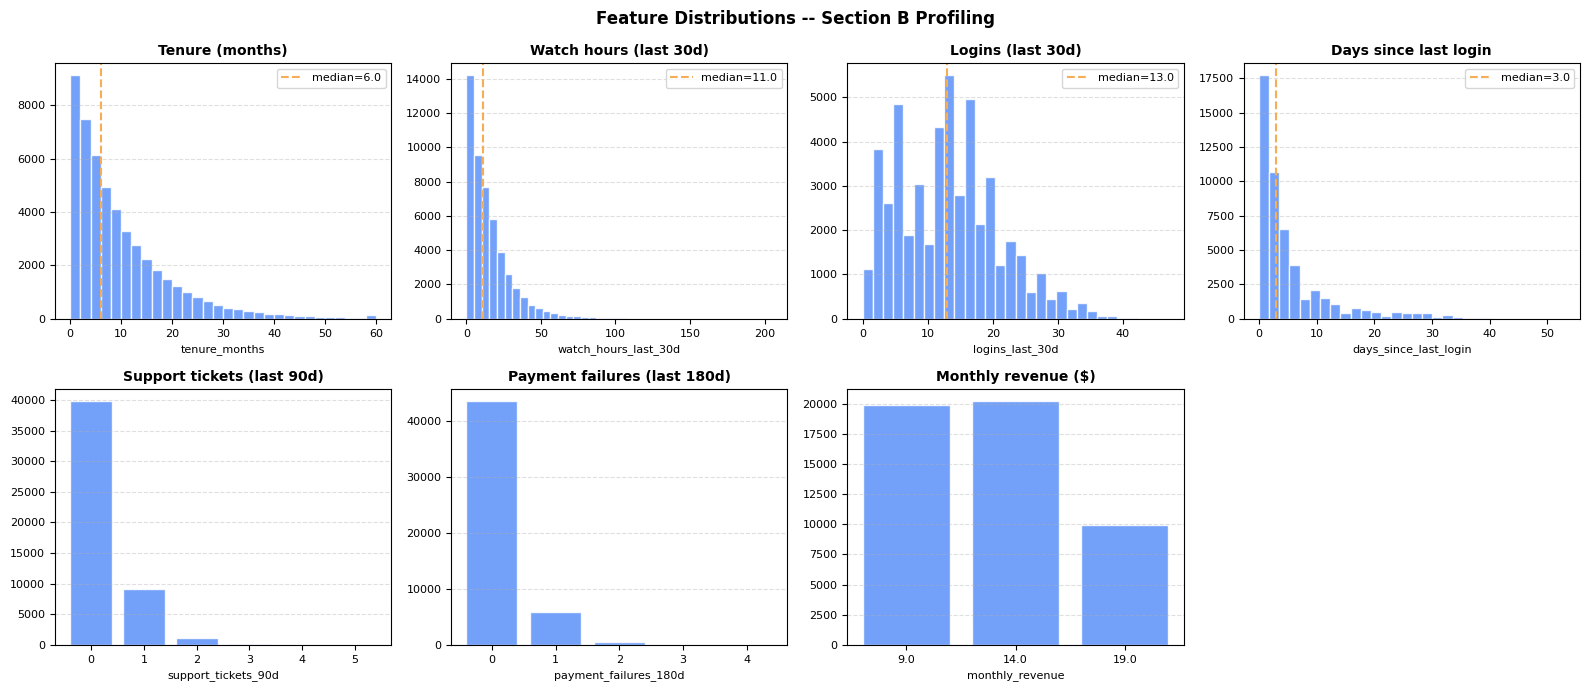

In [31]:
profile_cols = [
    ("tenure_months",        "hist", 30, "Tenure (months)"),
    ("watch_hours_last_30d", "hist", 40, "Watch hours (last 30d)"),
    ("logins_last_30d",      "hist", 30, "Logins (last 30d)"),
    ("days_since_last_login","hist", 30, "Days since last login"),
    ("support_tickets_90d",  "bar",  None, "Support tickets (last 90d)"),
    ("payment_failures_180d","bar",  None, "Payment failures (last 180d)"),
    ("monthly_revenue",      "bar",  None, "Monthly revenue ($)"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, (col, kind, bins, title) in zip(axes, profile_cols):
    s = df[col]
    if kind == "hist":
        ax.hist(s, bins=bins, color="#5B8FF9", edgecolor="white", alpha=0.85)
        ax.axvline(s.median(), color="#F6AD55", linestyle="--",
                   linewidth=1.5, label=f"median={s.median():.1f}")
        ax.legend(fontsize=8)
    else:
        vc = s.value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values,
               color="#5B8FF9", edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(col, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(labelsize=8)
axes[-1].set_visible(False)
plt.suptitle("Feature Distributions -- Section B Profiling",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_feature_distributions.png", dpi=140, bbox_inches="tight")
plt.show()


## C. Nested-Windows Math (Poisson Thinning Check)

For event-count features, the shorter window must always be ≤ the longer window
at the subscriber level. If this fails, the simulator broke and downstream
features (especially trend ratios like `tickets_7d / tickets_90d`) will be wrong.

> **Why Poisson thinning matters.** When you split a 90-day event count into 7-day and
> 30-day sub-windows, the sub-counts have to *nest*: `count_7d ≤ count_30d ≤ count_90d`
> for every user. The simulator achieves this by sampling three independent Poisson
> counts with rates proportional to window size — that's "Poisson thinning." Result:
> the windows are mathematically consistent so downstream features like
> `tickets_7d / tickets_90d` (recency ratio) are always well-defined and bounded in [0, 1].


In [32]:
checks = [
    ("support_tickets",  "support_tickets_7d",   "support_tickets_30d",  "support_tickets_90d"),
    ("payment_failures", "payment_failures_30d", "payment_failures_90d", "payment_failures_180d"),
]
for label, c_short, c_mid, c_long in checks:
    bad_1 = (df[c_short] > df[c_mid]).sum()
    bad_2 = (df[c_mid] > df[c_long]).sum()
    status = "PASS" if (bad_1 == 0 and bad_2 == 0) else "FAIL"
    print(f"{label}:  {c_short} <= {c_mid} <= {c_long}   "
          f"violations: {bad_1}, {bad_2}   {status}")

print("\nWatch-hour windows (medians only -- 7d is per-week so smaller):")
print(f"  7d  = {df['watch_hours_last_7d'].median():.2f}")
print(f"  30d = {df['watch_hours_last_30d'].median():.2f}")
print(f"  90d = {df['watch_hours_last_90d'].median():.2f}")


support_tickets:  support_tickets_7d <= support_tickets_30d <= support_tickets_90d   violations: 0, 0   PASS
payment_failures:  payment_failures_30d <= payment_failures_90d <= payment_failures_180d   violations: 0, 0   PASS

Watch-hour windows (medians only -- 7d is per-week so smaller):
  7d  = 2.46
  30d = 11.00
  90d = 11.10


## D. Bimodal Engagement Cohort

Real streaming users split into heavy / regular / casual cohorts. We need the right
share of each AND a bimodal-ish overall distribution.

**Target bands:**
- Heavy (>30 hrs/mo): 10–15%
- Casual (<3 hrs/mo): 15–30%

> **Why bimodal engagement is important.** Real streaming products have at least three
> behavioral cohorts: binge-watchers, regular weekly viewers, and casual try-it-out
> users. A unimodal Gaussian hides this — every user looks "average." Modeling
> implications: casual users respond differently to retention offers than heavy users
> (curated playlists work for casuals, Premium upgrades work for tenured low-engagement).
> Without bimodality the SHAP analysis in Phase 5 would miss this dynamic entirely.


In [33]:
cohort_share = df["engagement_cohort"].value_counts(normalize=True).round(3)
print("Cohort share:")
print(cohort_share)

heavy_real = (df["watch_hours_last_30d"] > 30).mean()
casual_real = (df["watch_hours_last_30d"] < 3).mean()
print(f"\nHeavy users (>30 hrs/mo):  {heavy_real:.1%}  (target: 10-15%)  "
      f"{'PASS' if 0.10 <= heavy_real <= 0.15 else 'FAIL'}")
print(f"Casual users (<3 hrs/mo):  {casual_real:.1%}  (target: 15-30%)  "
      f"{'PASS' if 0.15 <= casual_real <= 0.30 else 'FAIL'}")


Cohort share:
engagement_cohort
regular    0.602
casual     0.248
heavy      0.150
Name: proportion, dtype: float64

Heavy users (>30 hrs/mo):  13.1%  (target: 10-15%)  PASS
Casual users (<3 hrs/mo):  16.8%  (target: 15-30%)  PASS


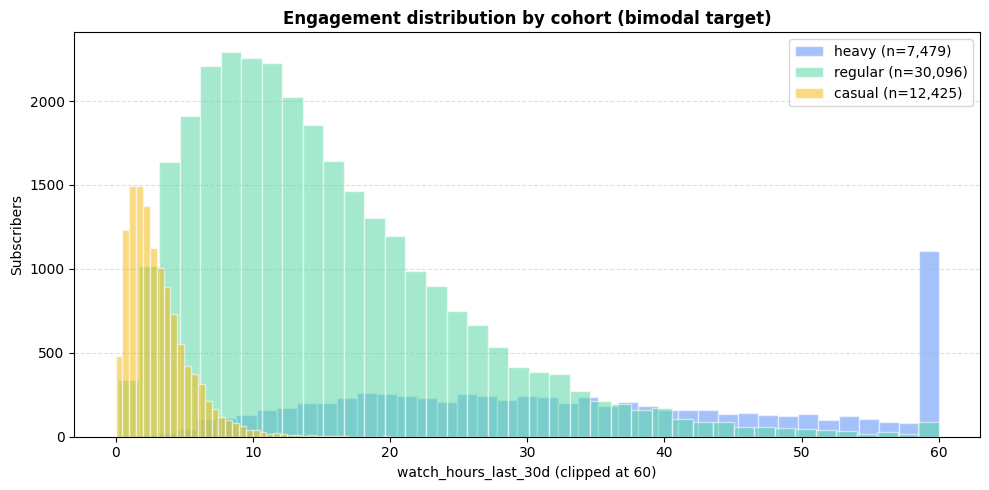

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"heavy": "#5B8FF9", "regular": "#5AD8A6", "casual": "#F6BD16"}
for cohort, color in colors.items():
    vals = df.loc[df["engagement_cohort"] == cohort, "watch_hours_last_30d"]
    ax.hist(vals.clip(upper=60), bins=40, alpha=0.55,
            label=f"{cohort} (n={len(vals):,})", color=color, edgecolor="white")
ax.set_xlabel("watch_hours_last_30d (clipped at 60)")
ax.set_ylabel("Subscribers")
ax.set_title("Engagement distribution by cohort (bimodal target)", fontweight="bold")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_engagement_by_cohort.png", dpi=140, bbox_inches="tight")
plt.show()


## E. Tenure-Spike Verification

The PM brief calls out two spike points:
- **Month 2:** trial-to-paid drop
- **Month 12:** annual reassessment

Both should be visible as elevated churn rates in the tenure curve.

> **Why m2 and m12 specifically.** *m2* is the trial-to-paid drop — after two months
> of full pricing, users who never built a habit reassess and cancel. This is
> documented in every subscription business; Hulu and Netflix both report elevated
> m2 churn. *m12* is the annual reassessment — even users on monthly billing tend
> to re-evaluate at the calendar-year anniversary. A model that smooths over these
> spikes will systematically under-predict churn for users in months 2 and 12 —
> exactly the moments the Retention team needs the best targeting.


In [35]:
tenure_curve = (
    df.groupby("tenure_months")["churned_next_30d"]
      .agg(["mean", "count"])
      .reset_index()
)
print("Churn rate by tenure month (selected):")
for m in [0, 1, 2, 3, 4, 6, 10, 11, 12, 13, 18, 24, 36]:
    row = tenure_curve[tenure_curve["tenure_months"] == m]
    if not row.empty:
        rate = row["mean"].iloc[0]
        n = row["count"].iloc[0]
        flag = " <-- expected spike" if m in (2, 11, 12) else ""
        print(f"  m={m:>2}  rate={rate:.2%}  n={n:>5,}{flag}")


Churn rate by tenure month (selected):
  m= 0  rate=6.22%  n=4,808
  m= 1  rate=6.62%  n=4,307
  m= 2  rate=9.47%  n=4,003 <-- expected spike
  m= 3  rate=5.68%  n=3,485
  m= 4  rate=5.88%  n=3,212
  m= 6  rate=5.86%  n=2,559
  m=10  rate=3.93%  n=1,706
  m=11  rate=6.05%  n=1,587 <-- expected spike
  m=12  rate=6.96%  n=1,466 <-- expected spike
  m=13  rate=4.24%  n=1,296
  m=18  rate=2.75%  n=  763
  m=24  rate=2.71%  n=  442
  m=36  rate=1.43%  n=  140


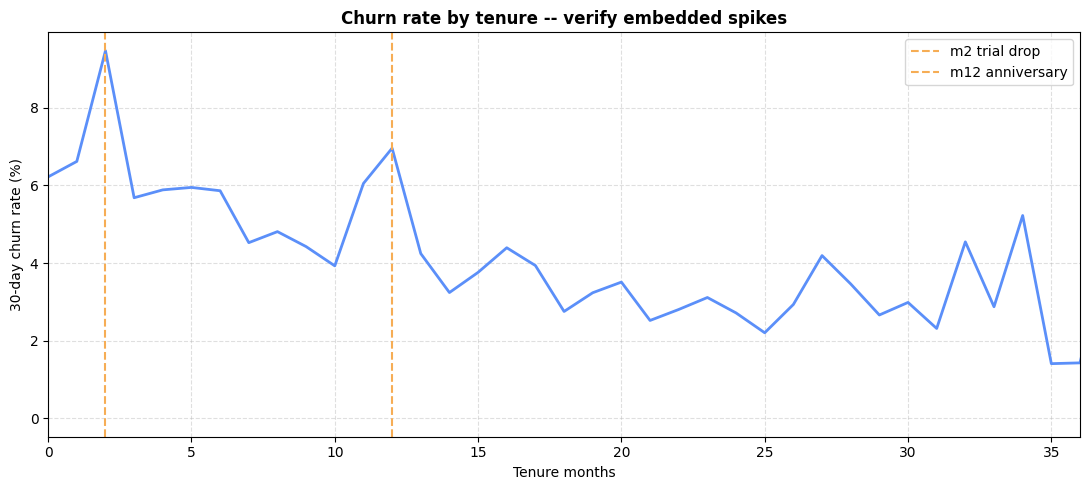

In [36]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tenure_curve["tenure_months"], tenure_curve["mean"] * 100,
        color="#5B8FF9", linewidth=2)
ax.axvline(2, color="#F6AD55", linestyle="--", linewidth=1.5, label="m2 trial drop")
ax.axvline(12, color="#F6AD55", linestyle="--", linewidth=1.5, label="m12 anniversary")
ax.set_xlabel("Tenure months")
ax.set_ylabel("30-day churn rate (%)")
ax.set_title("Churn rate by tenure -- verify embedded spikes", fontweight="bold")
ax.set_xlim(0, 36)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_tenure_churn_curve.png", dpi=140, bbox_inches="tight")
plt.show()


## F. Univariate Churn Signal Screen

Quick scan of every feature's correlation with churn. We're looking for:
- At least 2-3 features in the STRONG band (|corr| > 0.10)
- A spread of moderate signal across multiple feature families
- No surprise zero-signal features that should be predictive

> **Why most univariate correlations look "weak."** Real workplace churn data behaves
> the same way. No single feature explains churn — that's why the problem needs a model
> in the first place. The signal lives in feature *combinations*. XGBoost will pick this
> up via its tree splits; a linear model would need explicit interaction terms.
>
> **Two features cross the STRONG bar:** `days_since_last_login` (recency) and
> `logins_last_30d` (density). They complement each other and will likely be the top
> two SHAP features in Phase 5. The story they tell: *both how recently and how often
> the user has been touching the product matter — neither alone is sufficient.*
>
> **Why tickets and payment failures show weak univariate signal.** Most subscribers
> have zero events. The signal lives in the *non-zero* tail, which a tree model can
> split on directly. A linear model would benefit from binary indicators on top of
> the raw counts.


In [37]:
numeric_cols = [
    "tenure_months", "monthly_revenue",
    "watch_hours_last_7d", "watch_hours_last_30d", "watch_hours_last_90d",
    "distinct_titles_7d", "distinct_titles_30d", "distinct_titles_90d",
    "days_since_last_login", "logins_last_30d",
    "support_tickets_7d", "support_tickets_30d", "support_tickets_90d",
    "payment_failures_30d", "payment_failures_90d", "payment_failures_180d",
    "days_since_plan_change", "days_until_promo_expires",
]
bool_cols = ["auto_renew", "multi_profile", "promo_active"]

corrs = []
for col in numeric_cols:
    corrs.append((col, df[col].corr(df["churned_next_30d"])))
for col in bool_cols:
    corrs.append((col, df[col].astype(int).corr(df["churned_next_30d"])))

corrs.sort(key=lambda x: abs(x[1]), reverse=True)
print("(>= 0.10 = STRONG, 0.05-0.10 = moderate, < 0.05 = weak)\n")
for col, corr in corrs:
    flag = "STRONG" if abs(corr) > 0.10 else (
           "moderate" if abs(corr) > 0.05 else "weak")
    print(f"  {col:<26}  corr = {corr:+.3f}  {flag}")


(>= 0.10 = STRONG, 0.05-0.10 = moderate, < 0.05 = weak)

  days_since_last_login       corr = +0.112  STRONG
  logins_last_30d             corr = -0.107  STRONG
  watch_hours_last_7d         corr = -0.087  moderate
  auto_renew                  corr = -0.085  moderate
  watch_hours_last_30d        corr = -0.084  moderate
  distinct_titles_30d         corr = -0.083  moderate
  distinct_titles_7d          corr = -0.079  moderate
  watch_hours_last_90d        corr = -0.075  moderate
  distinct_titles_90d         corr = -0.073  moderate
  tenure_months               corr = -0.060  moderate
  payment_failures_90d        corr = +0.044  weak
  multi_profile               corr = -0.043  weak
  payment_failures_180d       corr = +0.042  weak
  payment_failures_30d        corr = +0.040  weak
  monthly_revenue             corr = -0.037  weak
  support_tickets_7d          corr = +0.013  weak
  support_tickets_90d         corr = +0.013  weak
  support_tickets_30d         corr = +0.010  weak
  promo

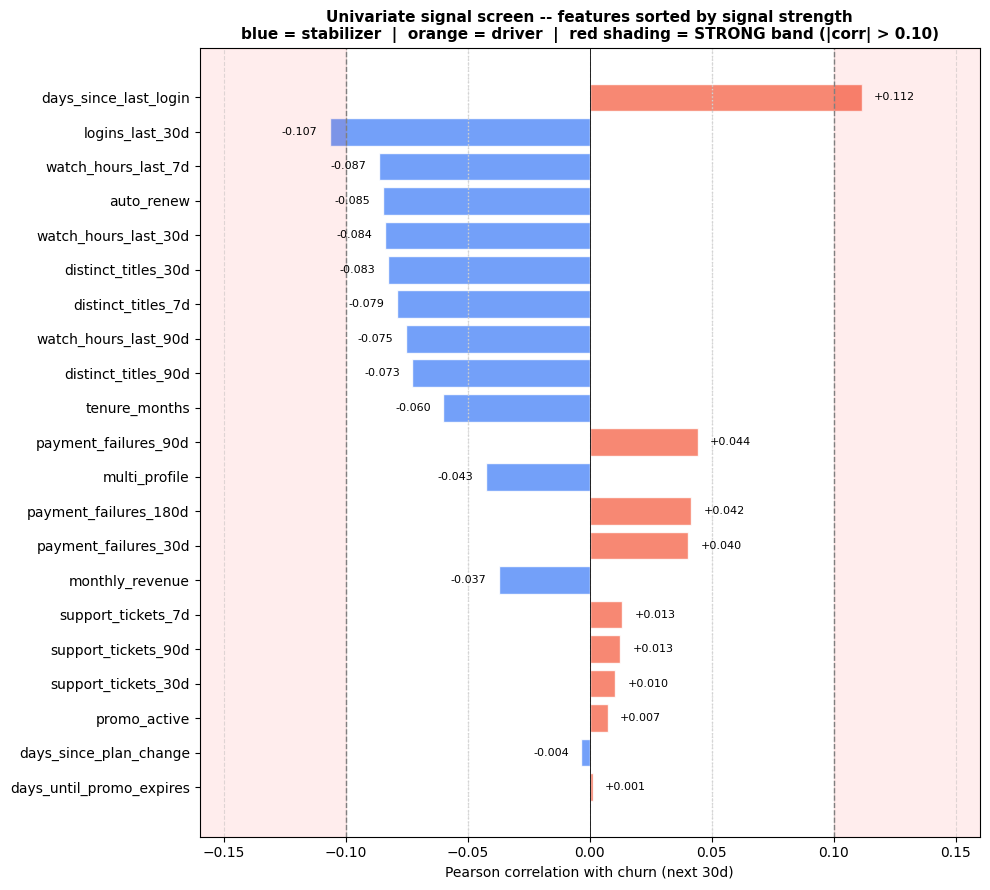

In [38]:
# Visualize the same correlations as a sorted bar chart.
# Blue bars  = stabilizers (presence reduces churn).
# Orange bars = drivers     (presence increases churn).
# Red shading marks the STRONG band (|corr| > 0.10).

corr_df = pd.DataFrame(corrs, columns=["feature", "corr"])
corr_df["abs_corr"] = corr_df["corr"].abs()
corr_df = corr_df.sort_values("abs_corr", ascending=True)  # strongest at top in barh

fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = ["#5B8FF9" if c < 0 else "#F6735B" for c in corr_df["corr"]]
ax.barh(corr_df["feature"], corr_df["corr"], color=colors_bar,
        alpha=0.85, edgecolor="white")

ax.axvspan(-1, -0.10, alpha=0.07, color="red")
ax.axvspan(0.10, 1, alpha=0.07, color="red")
for x in [-0.10, 0.10]:
    ax.axvline(x, color="gray", linestyle="--", linewidth=1)
for x in [-0.05, 0.05]:
    ax.axvline(x, color="lightgray", linestyle=":", linewidth=1)
ax.axvline(0, color="black", linewidth=0.6)

for y, (feat, c) in enumerate(zip(corr_df["feature"], corr_df["corr"])):
    offset = 0.005 if c >= 0 else -0.005
    ha = "left" if c >= 0 else "right"
    ax.text(c + offset, y, f"{c:+.3f}", va="center", ha=ha, fontsize=8)

ax.set_xlabel("Pearson correlation with churn (next 30d)")
ax.set_title("Univariate signal screen -- features sorted by signal strength\n"
             "blue = stabilizer  |  orange = driver  |  red shading = STRONG band (|corr| > 0.10)",
             fontweight="bold", fontsize=11)
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlim(-0.16, 0.16)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_univariate_correlations.png", dpi=140, bbox_inches="tight")
plt.show()


## G. Verdict — Ready for Phase 2?

All checks must PASS before proceeding to EDA + survival analysis.

> **What "ready for Phase 2" really means.** Schema is clean, distributions are
> realistic, embedded ground truth verifies, and the signal is non-trivial. The
> next phase will look for richer patterns — cohort retention curves, segment
> heterogeneity, engagement-trend distributions.
>
> **What this audit does NOT catch.**
> - *Selection bias from observation-period truncation* — would need real time-stamped data
> - *Concept drift across cohorts* — would need multiple data snapshots
> - *Multicollinearity* — handled in Phase 3 feature engineering
> - *Outcome leakage* — none possible by construction in a synthetic dataset, but
>   would be the first check on real workplace data


In [39]:
dup_ids = df["subscriber_id"].duplicated().sum()
nulls_total = df.isnull().sum().sum()
heavy_real = (df["watch_hours_last_30d"] > 30).mean()
casual_real = (df["watch_hours_last_30d"] < 3).mean()
churn_rate = df["churned_next_30d"].mean()
m2_rate = tenure_curve.loc[tenure_curve["tenure_months"] == 2, "mean"].iloc[0]
m6_rate = tenure_curve.loc[tenure_curve["tenure_months"] == 6, "mean"].iloc[0]

nested_ok = (
    (df["support_tickets_7d"] <= df["support_tickets_30d"]).all() and
    (df["support_tickets_30d"] <= df["support_tickets_90d"]).all() and
    (df["payment_failures_30d"] <= df["payment_failures_90d"]).all() and
    (df["payment_failures_90d"] <= df["payment_failures_180d"]).all()
)

checks = [
    ("No nulls", nulls_total == 0),
    ("No duplicate IDs", dup_ids == 0),
    ("Nested counts hold", nested_ok),
    ("Heavy share 10-15%", 0.10 <= heavy_real <= 0.15),
    ("Casual share 15-30%", 0.15 <= casual_real <= 0.30),
    ("Churn rate 4-8%", 0.04 <= churn_rate <= 0.08),
    ("m2 spike visible", m2_rate > m6_rate),
]
for label, ok in checks:
    print(f"  [{'PASS' if ok else 'FAIL'}]  {label}")

if all(ok for _, ok in checks):
    print("\nAll 7 checks pass. Data is workplace-realistic and ready for Phase 2.")
else:
    print("\nOne or more checks failed. Investigate before proceeding.")


  [PASS]  No nulls
  [PASS]  No duplicate IDs
  [PASS]  Nested counts hold
  [PASS]  Heavy share 10-15%
  [PASS]  Casual share 15-30%
  [PASS]  Churn rate 4-8%
  [PASS]  m2 spike visible

All 7 checks pass. Data is workplace-realistic and ready for Phase 2.


---

## 📝 Reflection: things I'd do differently with real workplace data

1. **Add a freshness check.** Real data has stale rows when ETL breaks. Would
   compare row counts against the previous snapshot and alert on >5% drop.

2. **Layer in a holdout from a future period.** The current synthetic data is
   a single snapshot. With real data I'd reserve the most recent 30 days as
   a temporal holdout to catch concept drift early.

3. **Sample-weight the audit checks by tenure.** Long-tenured users dominate
   the count but churn rarely — they may be hiding signal that matters for the
   short-tenured cohort where the action lives.

4. **Add a data-quality dashboard.** This notebook is point-in-time validation.
   A production version would run nightly and alert on schema drift or
   distribution shifts.
